# Plotting notebook


**Sections**
1. Setup & shared helpers
2. Detector geometry (macro calorimeter box)
3. Cubelet occupancy (3D voxels)
4. Radial sectioning regions
5. Target distributions (energy + centroids)
6. Energy-group projections (2D scatter)
7. Multi-threshold encoding (signal → spikes)
8. Raw-event distributions (coordinate & energy maps)

Cubelet ID convention (1000 cubelets on a 10x10x10 grid):
`z = id // 100`, `y = (id % 100) // 10`, `x = id % 10`.


## 1. Setup & shared helpers

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Grid geometry
GRID_SIZE = 10
N_CUBELETS = 1000

# Default figure style
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

In [15]:
def decode_cubelet_ids(cubelet_ids):
    """Decode global cubelet IDs into (x, y, z) integer cell coordinates."""
    cubelet_ids = np.asarray(cubelet_ids).astype(int)
    z = cubelet_ids // 100
    y = (cubelet_ids % 100) // 10
    x = cubelet_ids % 10
    return x, y, z


def load_pt(file_path):
    """Load a cached .pt dataset and return its dict of tensors."""
    return torch.load(file_path, map_location="cpu")

In [16]:
def draw_solid_box(ax, origin, size, facecolor, edgecolor="black",
                   alpha=0.3, linewidth=1.0):
    """Draw a 3D box with solid, semi-transparent faces."""
    x, y, z = origin
    dx, dy, dz = size
    v = np.array([[x, y, z], [x+dx, y, z], [x+dx, y+dy, z], [x, y+dy, z],
                  [x, y, z+dz], [x+dx, y, z+dz], [x+dx, y+dy, z+dz], [x, y+dy, z+dz]])
    faces = [
        [v[0], v[1], v[5], v[4]], [v[1], v[2], v[6], v[5]],
        [v[2], v[3], v[7], v[6]], [v[3], v[0], v[4], v[7]],
        [v[0], v[1], v[2], v[3]], [v[4], v[5], v[6], v[7]],
    ]
    poly3d = Poly3DCollection(faces, alpha=alpha, facecolors=facecolor,
                              edgecolors=edgecolor, linewidths=linewidth)
    ax.add_collection3d(poly3d)


def add_physical_axes(ax, origin, len_z, len_x, len_y):
    """Add a triad of physical coordinate axes (x, y, z) as arrows."""
    ox, oy, oz = origin
    # Physical Z (plot X axis, beam direction)
    ax.quiver(ox, oy, oz, len_z, 0, 0, color="black", arrow_length_ratio=0.15, linewidth=1.5)
    ax.text(ox + len_z * 1.15, oy, oz, "z", color="black", fontsize=14, style="italic", weight="bold")
    # Physical X (plot Y axis, transverse)
    ax.quiver(ox, oy, oz, 0, len_x, 0, color="black", arrow_length_ratio=0.15, linewidth=1.5)
    ax.text(ox, oy + len_x * 1.15, oz, "x", color="black", fontsize=14, style="italic", weight="bold")
    # Physical Y (plot Z axis, vertical)
    ax.quiver(ox, oy, oz, 0, 0, len_y, color="black", arrow_length_ratio=0.15, linewidth=1.5)
    ax.text(ox, oy, oz + len_y * 1.4, "y", color="black", fontsize=14, style="italic", weight="bold")

In [17]:
def render_voxel_grid(filled, facecolors, title,
                      grid_size=GRID_SIZE, save_as=None,
                      elev=20, azim=-35, box_aspect=(1, 4, 1), zoom=0.75):
    """
    Render active voxels on an empty 3D wireframe grid.
    Shared by the cubelet-occupancy and radial-section figures.

    Axis convention in the plot: filled is indexed [x, z, y], so the plot axes
    are X (width), Z (depth) and Y (height).
    """
    fig = plt.figure(figsize=(16, 14), facecolor="white")
    ax = fig.add_subplot(111, projection="3d")

    # Remove matplotlib grid and panes
    ax.grid(False)
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor("white")

    # Manual empty wireframe
    line_w, line_alpha = 1.5, 0.3
    for i in range(grid_size + 1):
        for j in range(grid_size + 1):
            ax.plot([i, i], [j, j], [0, grid_size], color="gray", alpha=line_alpha, linewidth=line_w)
            ax.plot([i, i], [0, grid_size], [j, j], color="gray", alpha=line_alpha, linewidth=line_w)
            ax.plot([0, grid_size], [i, i], [j, j], color="gray", alpha=line_alpha, linewidth=line_w)

    # Active voxels
    ax.voxels(filled, facecolors=facecolors, edgecolors="black", linewidth=1.2)

    ax.set_xlabel("X coordinate", labelpad=40, fontsize=24)
    ax.set_ylabel("Z coordinate", labelpad=80, fontsize=24)
    ax.set_zlabel("Y coordinate", labelpad=40, fontsize=24)
    ax.set_title(title, fontsize=30, y=0.95)
    ax.tick_params(axis="both", which="major", labelsize=18)

    ax.set_box_aspect(box_aspect, zoom=zoom)
    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_zlim(0, grid_size)
    ax.view_init(elev=elev, azim=azim)
    fig.subplots_adjust(left=-0.05, right=1.05, bottom=-0.10, top=1.05)

    if save_as:
        plt.savefig(f"{save_as}.pdf", bbox_inches="tight", pad_inches=0.05)
        plt.savefig(f"{save_as}.png", dpi=300, bbox_inches="tight", pad_inches=0.05)
    plt.show()
    return ax

## 2. Detector geometry (macro calorimeter box)

The calorimeter as a single macro-volume (120 x 30 x 30 cm) drawn lying down,
with the 10x10x10 cubelet grid on the outer faces and the physical coordinate
triad. This is the cleanest version of the three original box drafts.

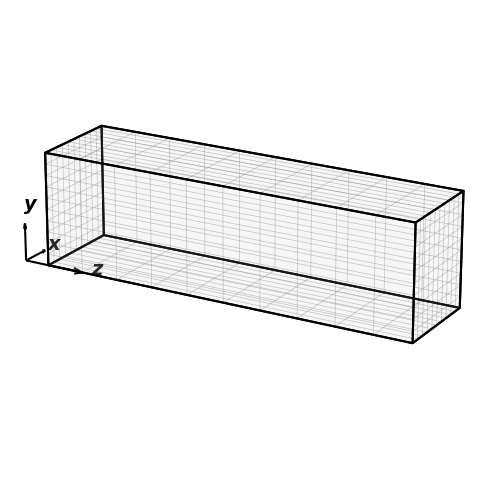

In [18]:
X_max, Y_max, Z_max = 120, 30, 30
dx, dy, dz = 12, 3, 3

fig = plt.figure(figsize=(10, 5), facecolor="white")
ax = fig.add_subplot(111, projection="3d")
ax.set_xlim([-10, X_max + 10]); ax.set_ylim([-5, Y_max]); ax.set_zlim([0, Z_max])

# Solid macro-volume
draw_solid_box(ax, (0, 0, 0), (X_max, Y_max, Z_max),
               facecolor="lightgray", alpha=0.1, linewidth=1.5)

# Grid only on the outer faces
for y in range(0, Y_max + 1, dy):
    for z in [0, Z_max]:
        ax.plot3D([0, X_max], [y, y], [z, z], color="gray", alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for y in [0, Y_max]:
        ax.plot3D([0, X_max], [y, y], [z, z], color="gray", alpha=0.5, linewidth=0.5)
for x in range(0, X_max + 1, dx):
    for z in [0, Z_max]:
        ax.plot3D([x, x], [0, Y_max], [z, z], color="gray", alpha=0.5, linewidth=0.5)
    for y in [0, Y_max]:
        ax.plot3D([x, x], [y, y], [0, Z_max], color="gray", alpha=0.5, linewidth=0.5)
for z in range(0, Z_max + 1, dz):
    for x in [0, X_max]:
        ax.plot3D([x, x], [0, Y_max], [z, z], color="gray", alpha=0.5, linewidth=0.5)
for y in range(0, Y_max + 1, dy):
    for x in [0, X_max]:
        ax.plot3D([x, x], [y, y], [0, Z_max], color="gray", alpha=0.5, linewidth=0.5)

add_physical_axes(ax, origin=(-8, 0, 0), len_z=20, len_x=10, len_y=10)

ax.set_box_aspect((X_max, Y_max, Z_max), zoom=1.1)
ax.set_axis_off()
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.savefig("calorimeter_geometry.pdf", bbox_inches="tight")
plt.savefig("calorimeter_geometry.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Cubelet occupancy (3D voxels)

Spatial distribution of the primary cubelets, rendered as filled voxels over
the empty grid. Set `PT_FILE` to the relevant cached dataset.

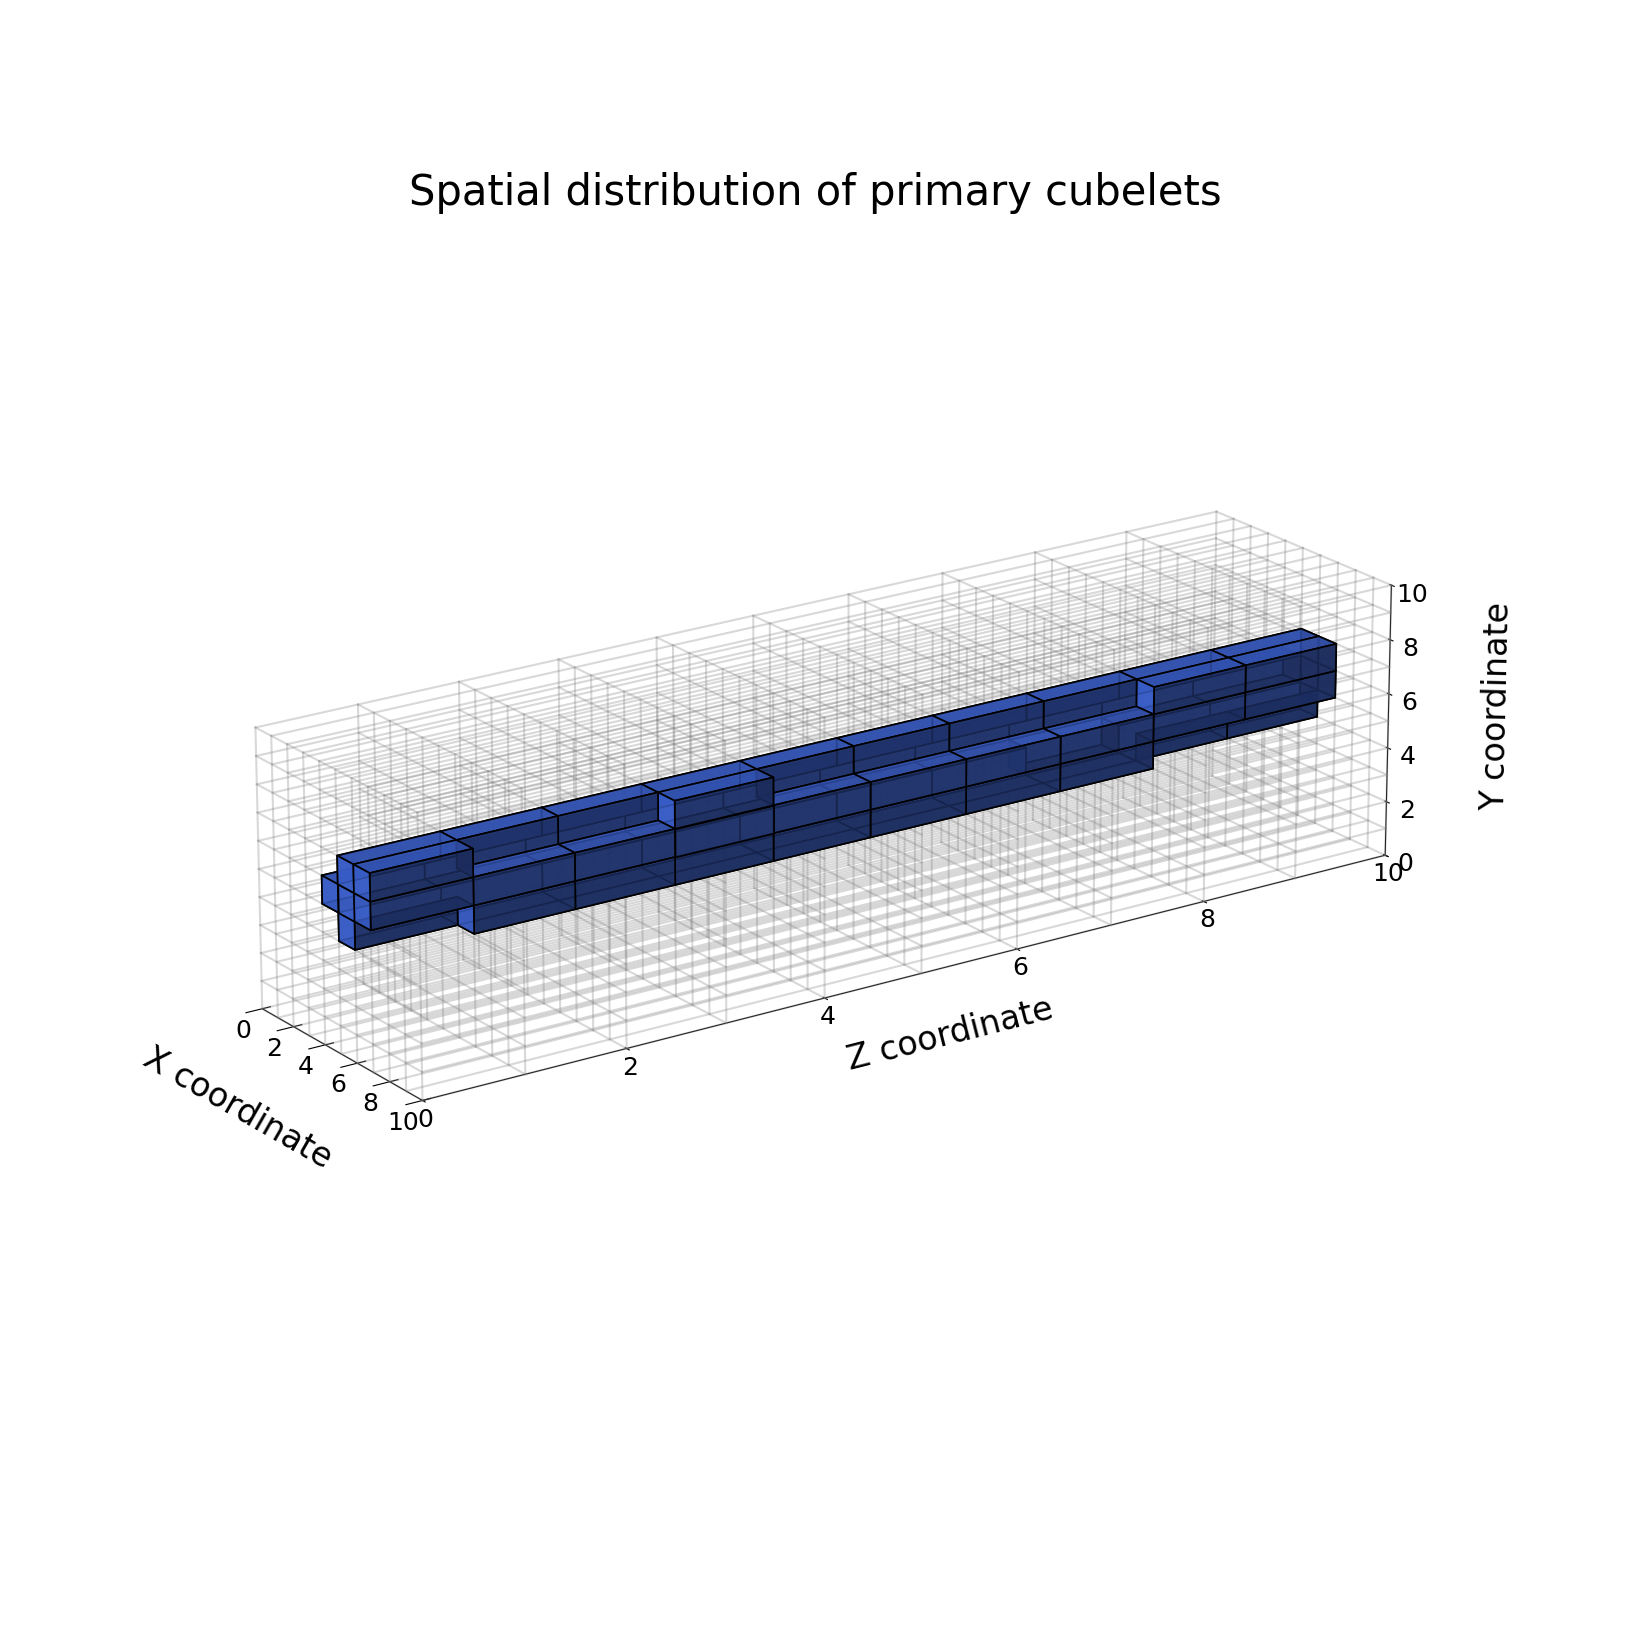

<Axes3D: title={'center': 'Spatial distribution of primary cubelets'}, xlabel='X coordinate', ylabel='Z coordinate', zlabel='Y coordinate'>

In [19]:
PT_FILE = "Dataset_Primaries.pt"

data = load_pt(PT_FILE)
x_idx, y_idx, z_idx = decode_cubelet_ids(data["cubelets"].numpy())

# Build the occupancy mask, indexed [x, z, y] for the plot orientation
filled = np.zeros((GRID_SIZE, GRID_SIZE, GRID_SIZE), dtype=bool)
for x, y, z in zip(x_idx, y_idx, z_idx):
    filled[x, z, y] = True

facecolors = np.zeros(filled.shape + (4,))
facecolors[filled] = [0.25, 0.41, 0.88, 0.85]  # royal blue, almost opaque

render_voxel_grid(filled, facecolors,
                  title="Spatial distribution of primary cubelets",
                  save_as="cubelet_occupancy_3d")

## 4. Radial sectioning regions

The three radial regions used in the sectioning study, each rendered with the
same voxel helper. Regions are defined by the transverse radius around the
detector centre (4.5, 4.5).

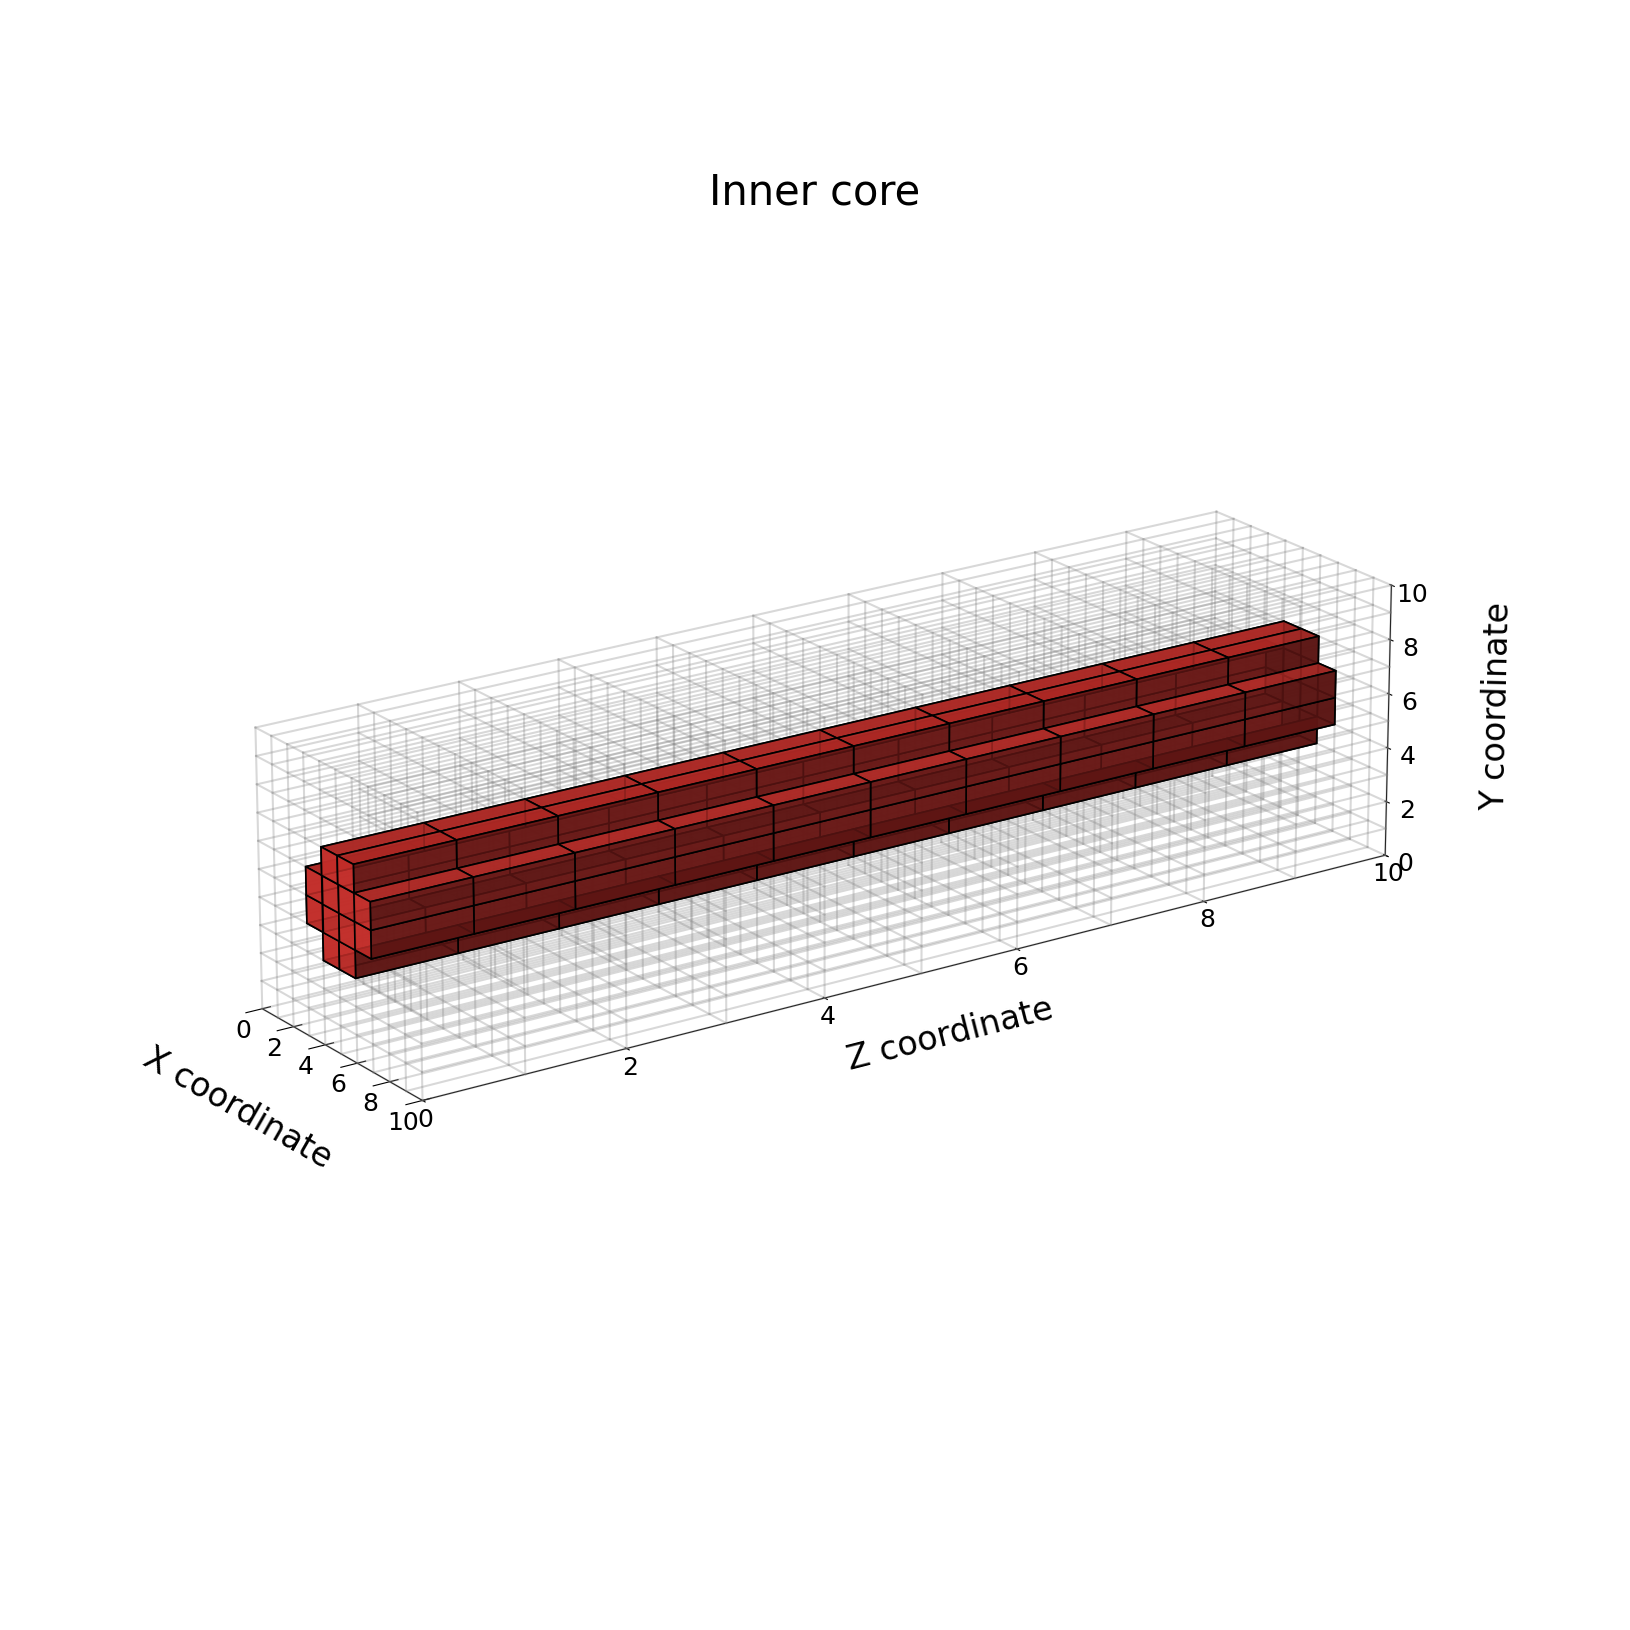

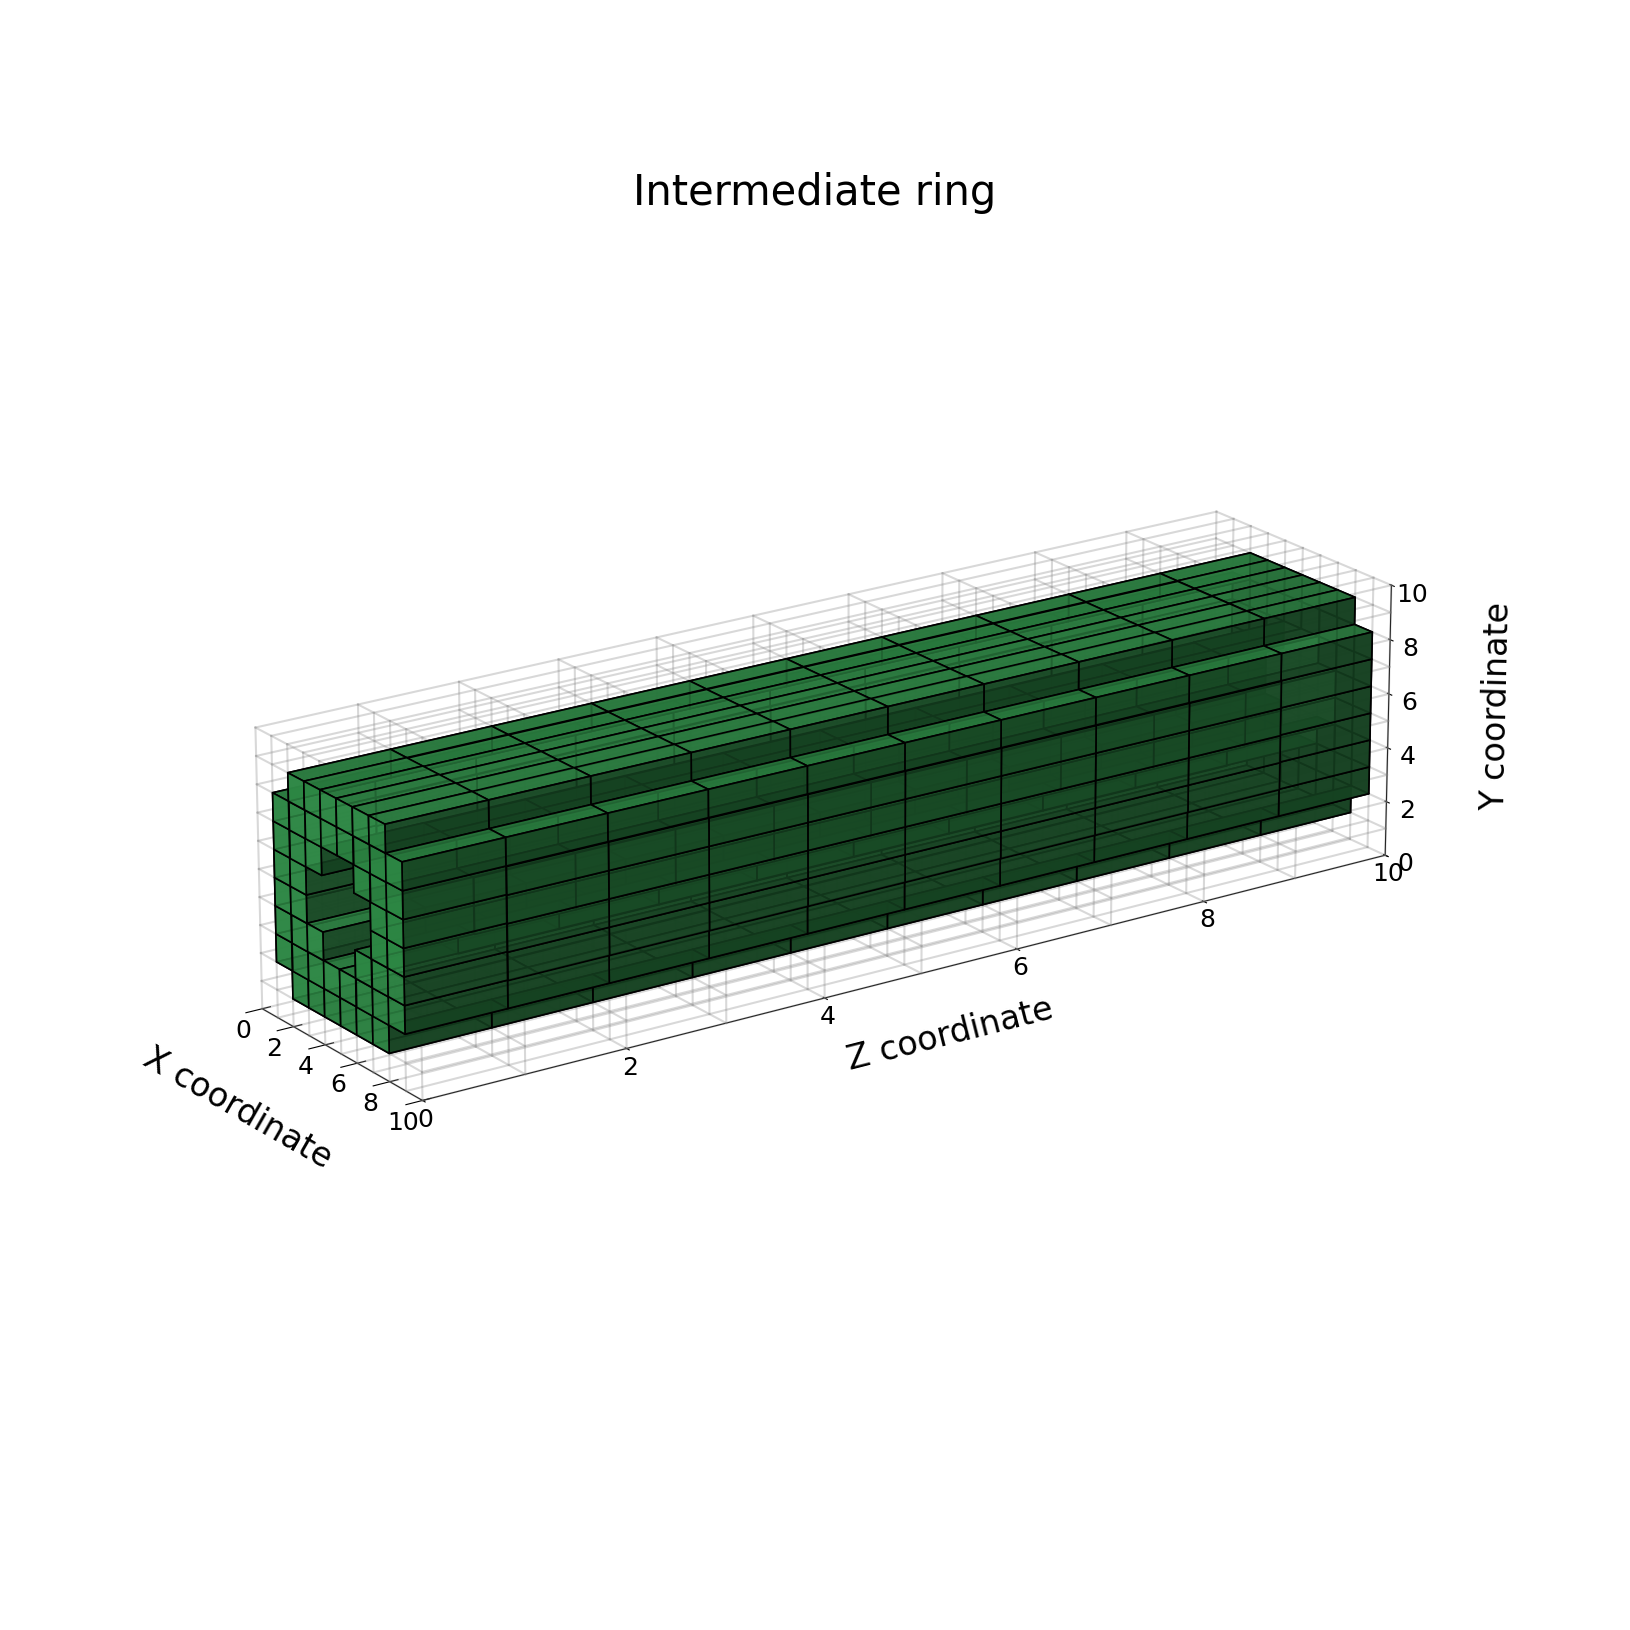

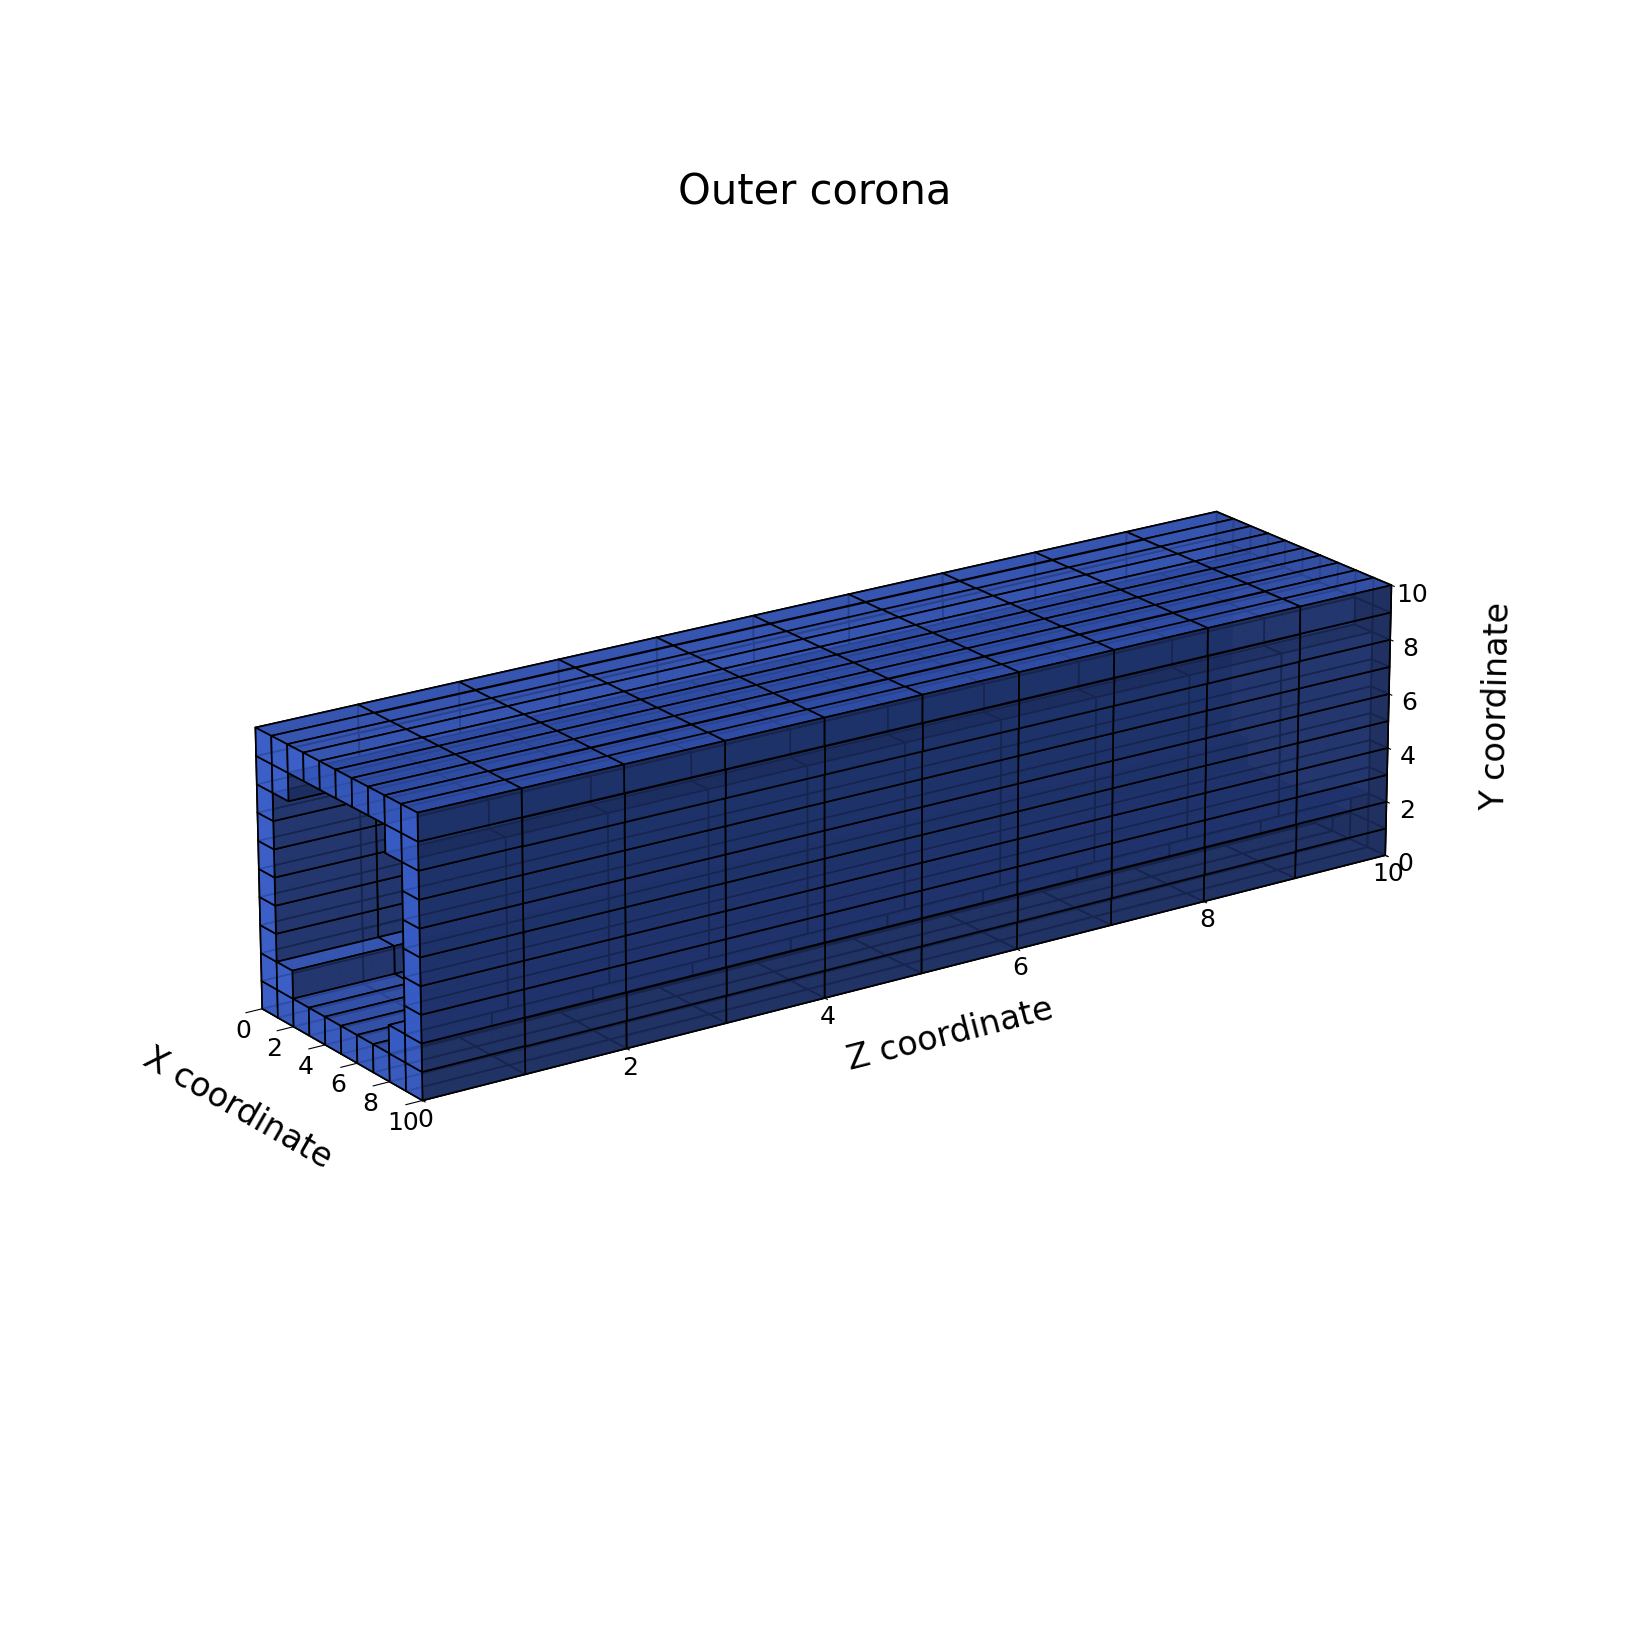

In [20]:
center_x, center_y = 4.5, 4.5

regions = [
    {"name": "Inner core",        "condition": lambda r: r < 2,
     "color": [0.86, 0.20, 0.18, 0.85], "file": "radial_section_inner"},
    {"name": "Intermediate ring", "condition": lambda r: (r >= 2) & (r < 4.5),
     "color": [0.20, 0.60, 0.30, 0.85], "file": "radial_section_middle"},
    {"name": "Outer corona",      "condition": lambda r: r >= 4.5,
     "color": [0.25, 0.41, 0.88, 0.85], "file": "radial_section_outer"},
]

for region in regions:
    filled = np.zeros((GRID_SIZE, GRID_SIZE, GRID_SIZE), dtype=bool)
    for x in range(GRID_SIZE):
        for y in range(GRID_SIZE):
            radius = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
            if region["condition"](radius):
                filled[x, :, y] = True  # fill all z layers

    facecolors = np.zeros(filled.shape + (4,))
    facecolors[filled] = region["color"]

    render_voxel_grid(filled, facecolors,
                      title=region["name"], save_as=region["file"])

## 5. Target distributions (energy + centroids)

Histograms of the four regression targets (log10 energy and the three centroid
coordinates). The same function serves both the full dataset and the primary
core; just change `pt_file` / `label`.

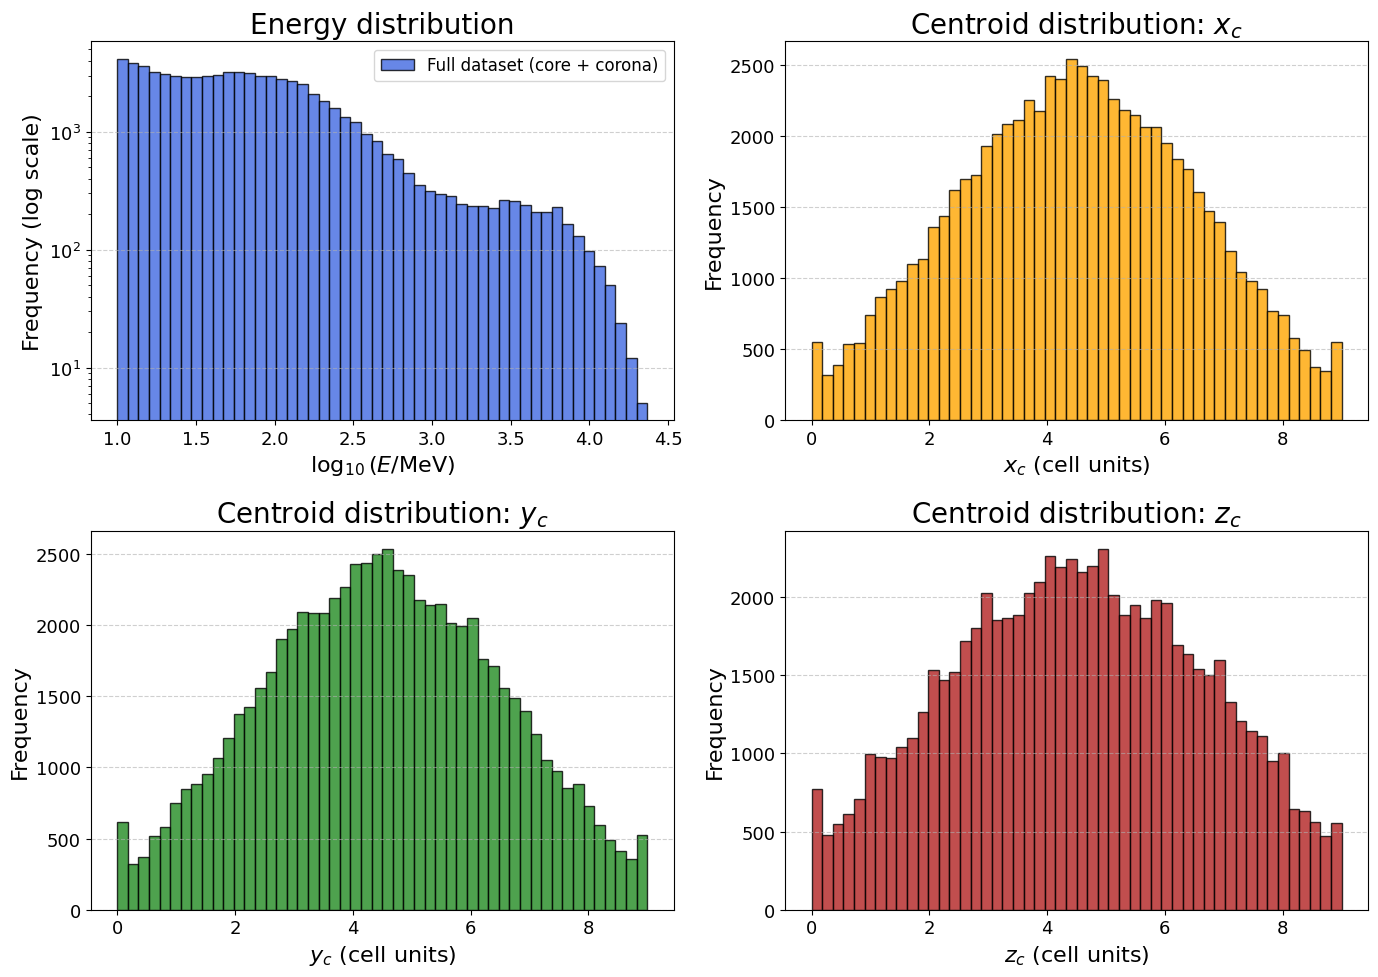

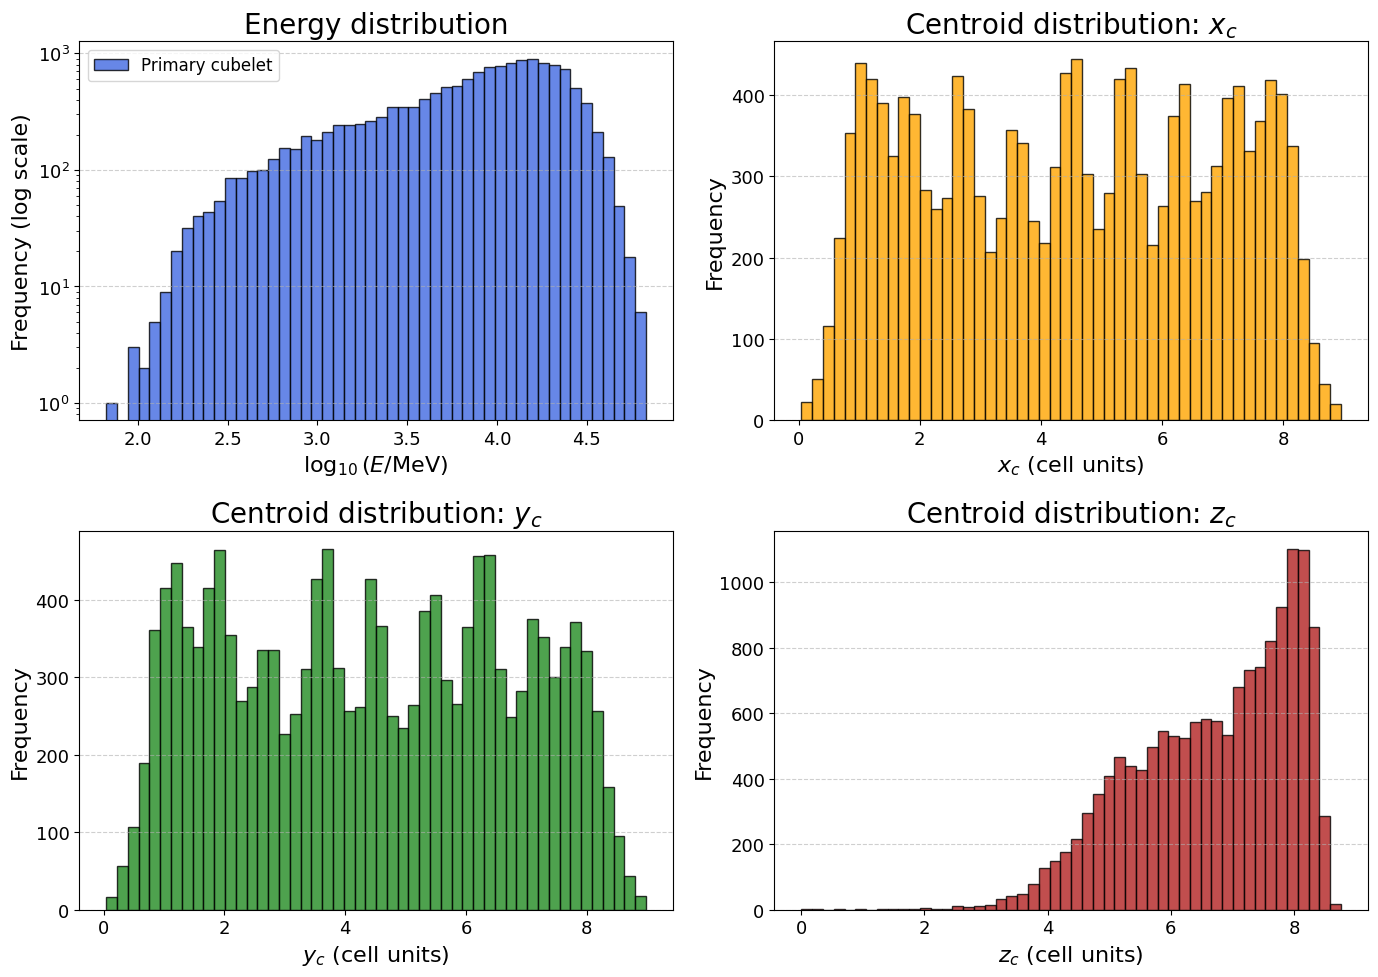

In [21]:
def plot_target_distributions(pt_file, energy_label, save_as):
    """2x2 histograms of log10(E) and the (x, y, z) centroid coordinates."""
    data = load_pt(pt_file)
    targets = data["targets"].numpy()
    log_E, x_c, y_c, z_c = targets[:, 0], targets[:, 1], targets[:, 2], targets[:, 3]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="white")
    axes = axes.flatten()

    axes[0].hist(log_E, bins=50, color="royalblue", edgecolor="black",
                 alpha=0.8, log=True, label=energy_label)
    axes[0].set_title("Energy distribution", fontsize=20)
    axes[0].set_xlabel(r"$\log_{10}(E/\mathrm{MeV})$", fontsize=16)
    axes[0].set_ylabel("Frequency (log scale)", fontsize=16)
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)
    axes[0].legend(fontsize=12)

    coords = [(x_c, r"$x_c$", "orange"),
              (y_c, r"$y_c$", "forestgreen"),
              (z_c, r"$z_c$", "firebrick")]
    for i, (coord_data, label, color) in enumerate(coords, start=1):
        axes[i].hist(coord_data, bins=50, color=color, edgecolor="black", alpha=0.8)
        axes[i].set_title(f"Centroid distribution: {label}", fontsize=20)
        axes[i].set_xlabel(f"{label} (cell units)", fontsize=16)
        axes[i].set_ylabel("Frequency", fontsize=16)
        axes[i].grid(axis="y", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.savefig(f"{save_as}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{save_as}.pdf", bbox_inches="tight")
    plt.show()


# Full dataset (core + corona)
plot_target_distributions("Dataset_Total.pt",
                          energy_label="Full dataset (core + corona)",
                          save_as="target_distributions_total")

# Primary core only
plot_target_distributions("Dataset_Primaries.pt",
                          energy_label="Primary cubelet",
                          save_as="target_distributions_primary_core")

## 6. Energy-group projections (2D scatter)

Accumulated transverse (X-Y) and longitudinal (Z-X) projections of all
cubelets, coloured by energy group. Jitter is added so overlapping integer
cells remain visible; the inner core is drawn last to stay on top.

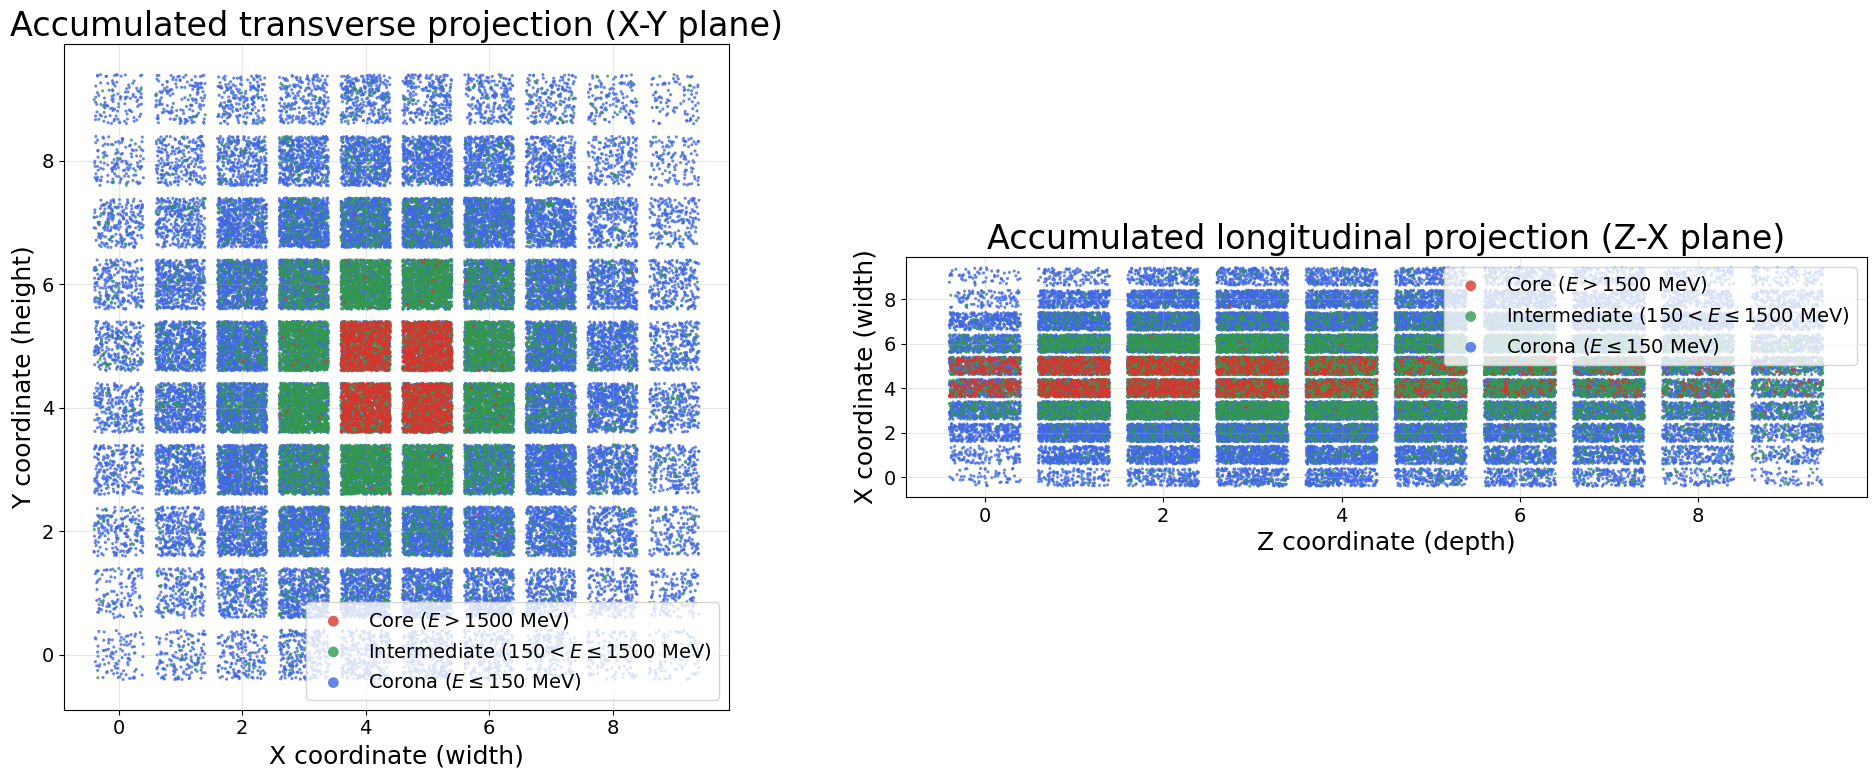

In [22]:
def plot_energy_group_projections(pt_file, save_as,
                                  e_high=1500, e_low=150,
                                  jitter=0.4, size_val=5, alpha_val=0.8):
    """Front (X-Y) and side (Z-X) scatter projections grouped by energy."""
    data = load_pt(pt_file)
    targets = data["targets"].numpy()
    x_idx, y_idx, z_idx = decode_cubelet_ids(data["cubelets"].numpy())
    E_abs = 10 ** targets[:, 0]  # undo log10 -> MeV

    groups = np.zeros_like(E_abs, dtype=int)
    groups[(E_abs <= e_high) & (E_abs > e_low)] = 1
    groups[E_abs <= e_low] = 2

    colors = ["#db332e", "#33994d", "#4069e0"]
    labels = [rf"Core ($E > {e_high}$ MeV)",
              rf"Intermediate (${e_low} < E \leq {e_high}$ MeV)",
              rf"Corona ($E \leq {e_low}$ MeV)"]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor="white")

    # Front view (X vs Y): draw corona first, core on top (reverse order)
    for i in [2, 1, 0]:
        mask = groups == i
        jx = np.random.uniform(-jitter, jitter, size=np.sum(mask))
        jy = np.random.uniform(-jitter, jitter, size=np.sum(mask))
        axes[0].scatter(x_idx[mask] + jx, y_idx[mask] + jy, c=colors[i],
                        label=labels[i], s=size_val, alpha=alpha_val,
                        edgecolors="none", zorder=3 - i)
    axes[0].set_title("Accumulated transverse projection (X-Y plane)", fontsize=24)
    axes[0].set_xlabel("X coordinate (width)", fontsize=18)
    axes[0].set_ylabel("Y coordinate (height)", fontsize=18)
    axes[0].tick_params(axis="both", which="major", labelsize=14)
    axes[0].set_aspect("equal")
    axes[0].grid(True, alpha=0.3, zorder=0)
    handles, labels_leg = axes[0].get_legend_handles_labels()
    leg0 = axes[0].legend(handles[::-1], labels_leg[::-1], fontsize=14)
    for lh in leg0.legend_handles:
        lh.set_sizes([60])

    # Side view (Z vs X)
    for i in [2, 1, 0]:
        mask = groups == i
        jz = np.random.uniform(-jitter, jitter, size=np.sum(mask))
        jx = np.random.uniform(-jitter, jitter, size=np.sum(mask))
        axes[1].scatter(z_idx[mask] + jz, x_idx[mask] + jx, c=colors[i],
                        label=labels[i], s=size_val, alpha=alpha_val,
                        edgecolors="none", zorder=3 - i)
    axes[1].set_title("Accumulated longitudinal projection (Z-X plane)", fontsize=24)
    axes[1].set_xlabel("Z coordinate (depth)", fontsize=18)
    axes[1].set_ylabel("X coordinate (width)", fontsize=18)
    axes[1].tick_params(axis="both", which="major", labelsize=14)
    # Plot Y axis is X (weight 1), plot X axis is Z (weight 4) -> aspect 1/4
    axes[1].set_aspect(0.25)
    axes[1].grid(True, alpha=0.3, zorder=0)
    handles1, labels_leg1 = axes[1].get_legend_handles_labels()
    leg1 = axes[1].legend(handles1[::-1], labels_leg1[::-1], fontsize=14)
    for lh in leg1.legend_handles:
        lh.set_sizes([60])

    plt.tight_layout()
    plt.savefig(f"{save_as}.pdf", bbox_inches="tight")
    plt.savefig(f"{save_as}.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_energy_group_projections("Dataset_Total.pt", save_as="energy_group_projections")

## 7. Multi-threshold encoding (signal → spikes)

For the most luminous event/sensor, the analog photon-count signal (top) and
the resulting binary spike trains from the four fixed thresholds
(10^2 ... 10^5) shown as a raster (bottom). This is the multi-threshold
encoding used by the spike generator.

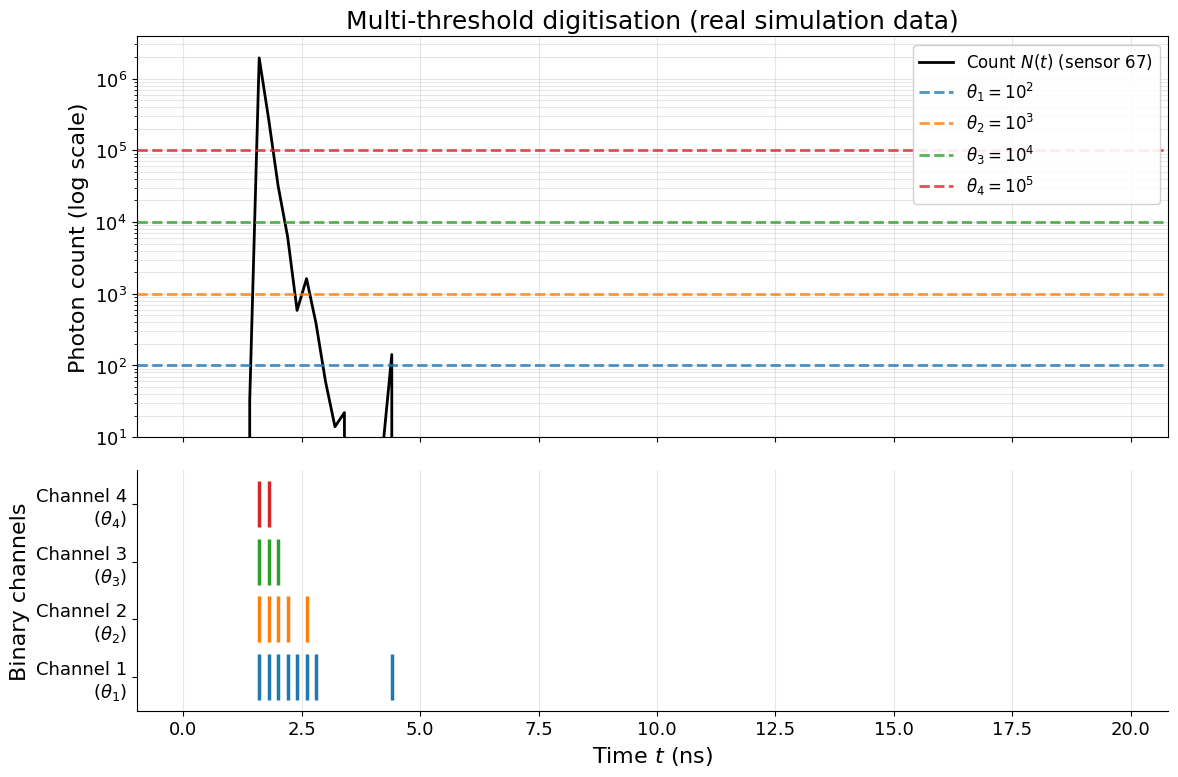

In [23]:
def plot_multithreshold_encoding(pt_file, multiplicity=4, dt=0.2, save_as=None):
    """Signal vs. fixed thresholds, and the resulting spike raster."""
    data = load_pt(pt_file)
    samples = data["samples"]  # (N_events, 100 time bins, 100 sensors)

    # Most luminous event, then its most luminous sensor
    best_event_idx = torch.argmax(samples.sum(dim=(1, 2))).item()
    event_data = samples[best_event_idx]                       # (100, 100)
    best_sensor_idx = torch.argmax(event_data.sum(dim=0)).item()
    signal = event_data[:, best_sensor_idx].numpy()

    n_bins = signal.shape[0]
    t = np.arange(n_bins) * dt  # physical time (ns)

    thresholds = [10 ** (i + 2) for i in range(multiplicity)]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1.2]})
    fig.patch.set_facecolor("white")

    # Top: analog signal with thresholds
    ax1.plot(t, signal, color="black", linewidth=2,
             label=f"Count $N(t)$ (sensor {best_sensor_idx})")
    for i, th in enumerate(thresholds):
        ax1.axhline(th, color=colors[i], linestyle="--", linewidth=2, alpha=0.8,
                    label=rf"$\theta_{i+1} = 10^{i+2}$")
    ax1.set_yscale("log")
    ax1.set_ylim(10, max(signal.max() * 2, 2 * 10 ** 5))
    ax1.set_ylabel("Photon count (log scale)")
    ax1.set_title("Multi-threshold digitisation (real simulation data)")
    ax1.legend(loc="upper right", framealpha=0.9)
    ax1.grid(True, which="both", alpha=0.3)

    # Bottom: spike raster (strict Heaviside)
    for i, th in enumerate(thresholds):
        spike_times = t[signal >= th]
        if len(spike_times) > 0:
            ax2.vlines(spike_times, i - 0.4, i + 0.4, color=colors[i], linewidth=2.5)
    ax2.set_yticks(range(multiplicity))
    ax2.set_yticklabels([rf"Channel {i+1}" + "\n" + rf"($\theta_{i+1}$)"
                         for i in range(multiplicity)])
    ax2.set_xlabel("Time $t$ (ns)")
    ax2.set_ylabel("Binary channels")
    ax2.grid(True, axis="x", alpha=0.3)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    plt.tight_layout()
    if save_as:
        plt.savefig(f"{save_as}.pdf", bbox_inches="tight")
        plt.savefig(f"{save_as}.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_multithreshold_encoding("Dataset_Primaries.pt",
                             save_as="multithreshold_encoding")

## 8. Raw-event distributions (coordinate & energy maps)

These figures read the raw dataset directly (via `dataset.py`) rather than a
cached `.pt`. The complete-event reconstruction (grouping cubelets into events
by the cubelet-ID ordering) is done **once** in `reconstruct_events`, and every
subsequent plot reuses its output.

In [24]:
import dataset as ds


def reconstruct_events(ds_all, n_cubelets=N_CUBELETS):
    """
    Group the flat (energy, cubelet_id, is_primary) stream into complete events.

    The number of files read is not a multiple of n_cubelets, so events cannot
    be sliced at fixed strides. Instead we accumulate cubelets until the
    cubelet_id stops increasing (a new event starts), assuming cubelets are
    stored in ascending ID order within an event.
    """
    events = []
    current_e = np.zeros(n_cubelets)
    current_p = np.zeros(n_cubelets, dtype=int)
    last_id = -1

    for d in ds_all:
        energy, cublet_id, is_primary = d[2]
        if cublet_id <= last_id:
            if np.sum(current_e) > 0:
                events.append((current_e, current_p))
            current_e = np.zeros(n_cubelets)
            current_p = np.zeros(n_cubelets, dtype=int)
        if 0 <= cublet_id < n_cubelets:
            current_e[cublet_id] = energy
            current_p[cublet_id] = is_primary
        last_id = cublet_id
    if np.sum(current_e) > 0:
        events.append((current_e, current_p))

    print(f"Reconstructed {len(events)} complete events.")
    return events


# Coordinate map for the 1000 cubelets (id -> x, y, z)
indices = np.arange(N_CUBELETS)
coords_all = np.column_stack([indices % 10, (indices % 100) // 10, indices // 100])

In [25]:
# --- Load raw datasets once ---
# Primary-only (single cubelet per event)
ds_primary = ds.build_dataset("../Data/PrimaryOnly/Uniform", max_files=100,
                              primary_only=True, target=["energy", "cublet"])
data_p = np.array([d[2] for d in ds_primary])
p_energy = data_p[:, 0]
p_x, p_y, p_z = decode_cubelet_ids(data_p[:, 1])

# Full readout (all cubelets, with primary flag)
ds_all = ds.build_dataset("../Data/All", max_files=20,
                          primary_only=False, target=["energy", "cublet", "primary"])
events = reconstruct_events(ds_all)

# Per-cubelet energy vs distance to the primary, computed once
all_distances, all_energies = [], []
for e_map, p_map in events:
    if np.sum(p_map) == 0:
        continue
    ip = np.where(p_map == 1)[0][0]
    p_coord = coords_all[ip]
    all_distances.append(np.linalg.norm(coords_all - p_coord, axis=1))
    all_energies.append(e_map)
all_distances = np.concatenate(all_distances)
all_energies = np.concatenate(all_energies)

Reconstructed 60 complete events.


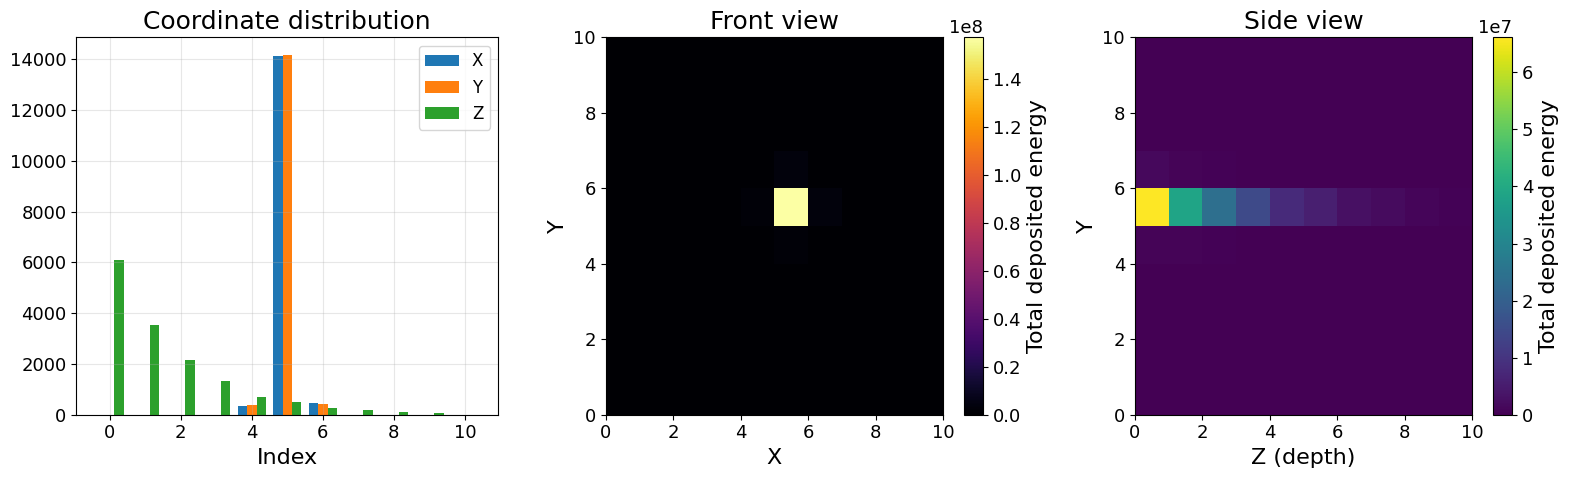

In [26]:
# --- Primary-only: coordinate histogram + energy-weighted views ---
fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.hist([p_x, p_y, p_z], bins=np.arange(0, 12) - 0.5,
         label=["X", "Y", "Z"], linewidth=2)
ax1.set_title("Coordinate distribution")
ax1.set_xlabel("Index"); ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(1, 3, 2)
h2 = ax2.hist2d(p_x, p_y, weights=p_energy,
                bins=[np.arange(11), np.arange(11)], cmap="inferno")
fig.colorbar(h2[3], ax=ax2, label="Total deposited energy")
ax2.set_title("Front view"); ax2.set_xlabel("X"); ax2.set_ylabel("Y")

ax3 = fig.add_subplot(1, 3, 3)
h3 = ax3.hist2d(p_z, p_y, weights=p_energy,
                bins=[np.arange(11), np.arange(11)], cmap="viridis")
fig.colorbar(h3[3], ax=ax3, label="Total deposited energy")
ax3.set_title("Side view"); ax3.set_xlabel("Z (depth)"); ax3.set_ylabel("Y")

plt.tight_layout()
plt.show()

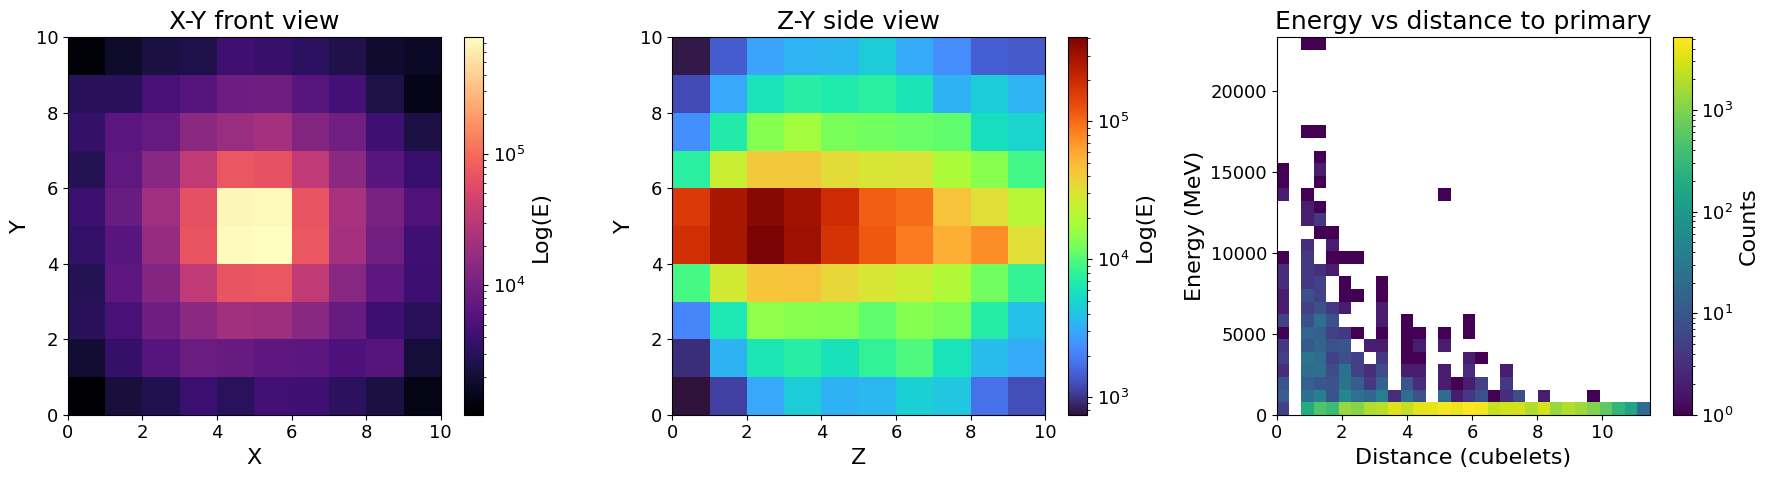

In [27]:
# --- Full readout: energy-weighted views + energy vs distance to primary ---
data_a = np.array([d[2] for d in ds_all])
a_energy = data_a[:, 0]
a_x, a_y, a_z = decode_cubelet_ids(data_a[:, 1])

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
h1 = ax1.hist2d(a_x, a_y, weights=a_energy,
                bins=[np.arange(11), np.arange(11)], cmap="magma", norm=LogNorm())
fig.colorbar(h1[3], ax=ax1, label="Log(E)")
ax1.set_title("X-Y front view"); ax1.set_xlabel("X"); ax1.set_ylabel("Y")

ax2 = fig.add_subplot(1, 3, 2)
h2 = ax2.hist2d(a_z, a_y, weights=a_energy,
                bins=[np.arange(11), np.arange(11)], cmap="turbo", norm=LogNorm())
fig.colorbar(h2[3], ax=ax2, label="Log(E)")
ax2.set_title("Z-Y side view"); ax2.set_xlabel("Z"); ax2.set_ylabel("Y")

ax3 = fig.add_subplot(1, 3, 3)
h3 = ax3.hist2d(all_distances, all_energies, bins=30, cmap="viridis", norm=LogNorm())
fig.colorbar(h3[3], ax=ax3, label="Counts")
ax3.set_title("Energy vs distance to primary")
ax3.set_xlabel("Distance (cubelets)"); ax3.set_ylabel("Energy (MeV)")

plt.tight_layout()
plt.show()

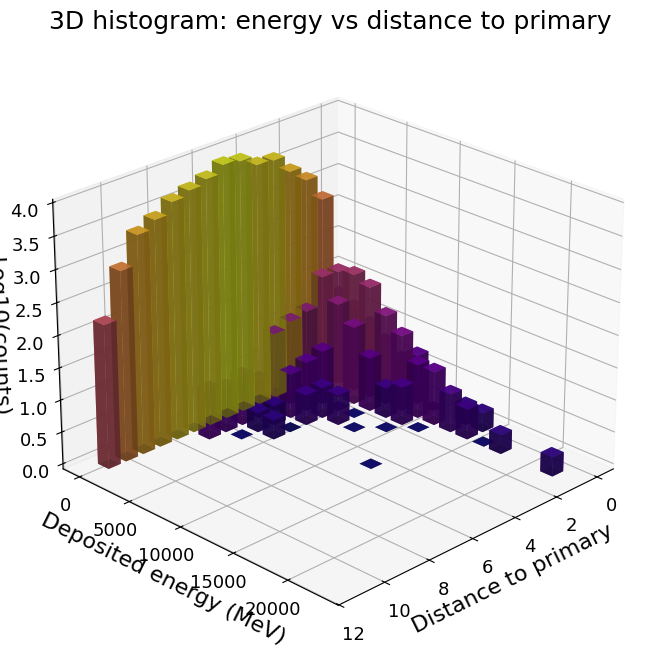

In [28]:
# --- Energy vs distance to primary, as a 3D histogram (log counts) ---
nbins_dist, nbins_ener = 15, 15
hist, d_edges, e_edges = np.histogram2d(all_distances, all_energies,
                                        bins=[nbins_dist, nbins_ener])

d_pos, e_pos = np.meshgrid(d_edges[:-1], e_edges[:-1], indexing="ij")
dz = hist.ravel()
mask = dz > 0

d_f = d_pos.ravel()[mask]
e_f = e_pos.ravel()[mask]
z_f = np.zeros_like(d_f)
dz_log = np.log10(dz[mask])
dd_f = np.ones_like(dz_log) * (d_edges[1] - d_edges[0]) * 0.7
de_f = np.ones_like(dz_log) * (e_edges[1] - e_edges[0]) * 0.7

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
colors = plt.cm.plasma(dz_log / dz_log.max())
ax.bar3d(d_f, e_f, z_f, dd_f, de_f, dz_log, color=colors, shade=True, alpha=0.8)
ax.set_title("3D histogram: energy vs distance to primary")
ax.set_xlabel("Distance to primary")
ax.set_ylabel("Deposited energy (MeV)")
ax.set_zlabel("Log10(counts)")
ax.view_init(elev=25, azim=45)
plt.show()

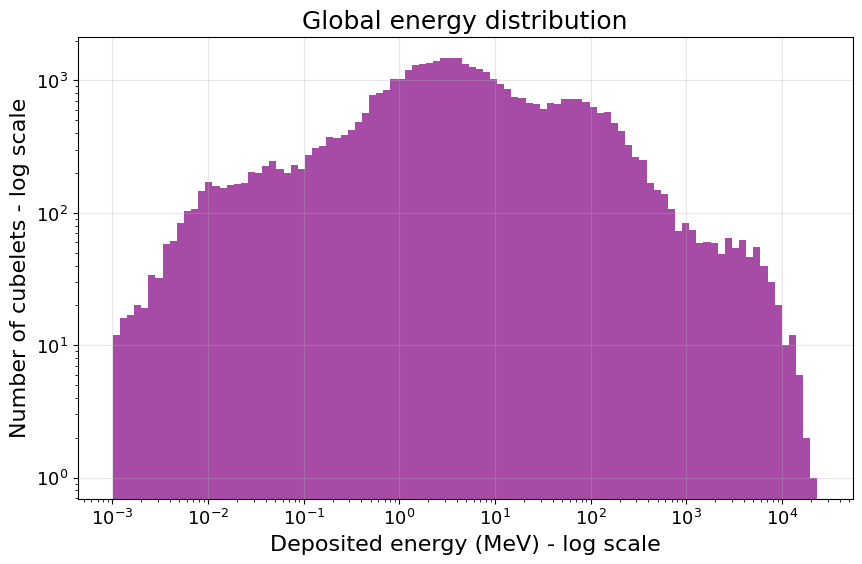

Minimum energy: 0.0010
Mean energy:    98.5367
Maximum energy: 23314.6381


In [29]:
# --- Global energy distribution of all cubelets (log-log) ---
all_e = np.concatenate([e for e, p in events])
valid_e = all_e[all_e > 0]

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.logspace(np.log10(valid_e.min()), np.log10(valid_e.max()), 100)
ax.hist(valid_e, bins=bins, color="purple", alpha=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Deposited energy (MeV) - log scale")
ax.set_ylabel("Number of cubelets - log scale")
ax.set_title("Global energy distribution")
ax.grid(alpha=0.3)
plt.show()

print(f"Minimum energy: {valid_e.min():.4f}")
print(f"Mean energy:    {valid_e.mean():.4f}")
print(f"Maximum energy: {valid_e.max():.4f}")

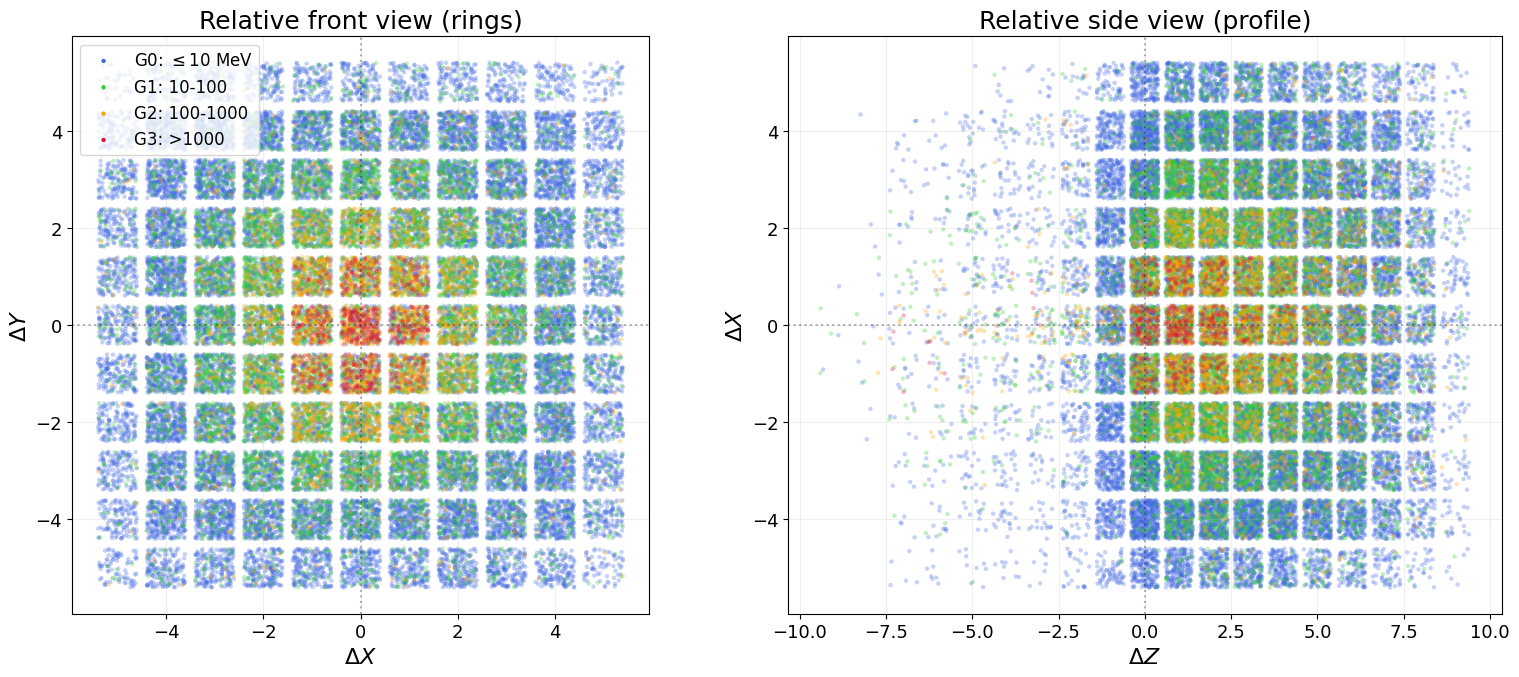

In [30]:
# --- Energy-group scatter relative to the primary cubelet (front + side) ---
TH1, TH2, TH3 = 10, 100, 1000
group_colors = ["royalblue", "limegreen", "orange", "crimson"]
group_labels = [rf"G0: $\leq${TH1} MeV", rf"G1: {TH1}-{TH2}",
                rf"G2: {TH2}-{TH3}", rf"G3: >{TH3}"]

abs_x, abs_y, abs_z = [], [], []
rel_x, rel_y, rel_z = [], [], []
groups = []

for e_map, p_map in events:
    if np.sum(p_map) == 0:
        continue
    ip = np.where(p_map == 1)[0][0]
    p_coord = coords_all[ip]
    for idx in np.where(e_map > 0)[0]:
        energy = e_map[idx]
        if energy <= TH1:   grp = 0
        elif energy <= TH2: grp = 1
        elif energy <= TH3: grp = 2
        else:               grp = 3
        coord_abs = coords_all[idx]
        coord_rel = coord_abs - p_coord
        abs_x.append(coord_abs[0]); abs_y.append(coord_abs[1]); abs_z.append(coord_abs[2])
        rel_x.append(coord_rel[0]); rel_y.append(coord_rel[1]); rel_z.append(coord_rel[2])
        groups.append(grp)

abs_x, abs_y, abs_z = map(lambda a: np.array(a).flatten(), (abs_x, abs_y, abs_z))
rel_x, rel_y, rel_z = map(lambda a: np.array(a).flatten(), (rel_x, rel_y, rel_z))
groups = np.array(groups).flatten()

jitter, alpha_val, size_val = 0.4, 0.3, 10

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Front view, relative coordinates (rings)
for i in range(4):
    mask = groups == i
    if np.sum(mask) == 0:
        continue
    jx = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    jy = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    axes[0].scatter(rel_x[mask] + jx, rel_y[mask] + jy, c=group_colors[i],
                    label=group_labels[i], s=size_val, alpha=alpha_val, edgecolors="none")
axes[0].set_title("Relative front view (rings)")
axes[0].set_xlabel(r"$\Delta X$"); axes[0].set_ylabel(r"$\Delta Y$")
axes[0].axhline(0, c="k", ls=":", alpha=0.3); axes[0].axvline(0, c="k", ls=":", alpha=0.3)
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.2)
leg = axes[0].legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)

# Side view, relative coordinates (profile)
for i in range(4):
    mask = groups == i
    if np.sum(mask) == 0:
        continue
    jz = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    jx = np.random.uniform(-jitter, jitter, size=np.sum(mask))
    axes[1].scatter(rel_z[mask] + jz, rel_x[mask] + jx, c=group_colors[i],
                    label=group_labels[i], s=size_val, alpha=alpha_val, edgecolors="none")
axes[1].set_title("Relative side view (profile)")
axes[1].set_xlabel(r"$\Delta Z$"); axes[1].set_ylabel(r"$\Delta X$")
axes[1].axhline(0, c="k", ls=":", alpha=0.3); axes[1].axvline(0, c="k", ls=":", alpha=0.3)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()